In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations
from collections import defaultdict

from xgboost import XGBClassifier
from sklearn.model_selection import BaseCrossValidator, ParameterGrid
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score, recall_score, precision_score, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, log_loss, ConfusionMatrixDisplay
)
import joblib
import hashlib


In [15]:
# Import data:
# run script from the data_input file
#os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')
os.chdir('C:/Users/ccwis/OneDrive/Documents/1. MEng - Data Science/Project/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    
df_factor = df_factor.set_index('Date')

df = pd.read_csv("lagged_data.csv", parse_dates=['Date'])
df = df.set_index('Date')


data = pd.concat([df,df_factor], axis=1, join='inner')
data = data.ffill().bfill()

print(data)

            VolTermStructPC1  VolTermStructPC2  MichgnConcIndx  \
Date                                                             
2007-06-18        -25.971465          9.547910            87.1   
2007-06-25        -26.283643          9.787659            87.1   
2007-07-02        -26.283553          9.942312            88.3   
2007-07-09        -28.132090          9.679810            88.3   
2007-07-16        -27.003497         10.308379            88.3   
...                      ...               ...             ...   
2025-03-03         39.101360         -6.676525            71.7   
2025-03-10         36.115275         -7.968991            71.7   
2025-03-17         35.492793         -8.161898            71.7   
2025-03-24         39.950630         -6.962702            71.7   
2025-03-31         44.421245         -5.261720            64.7   

            RandPPP_Factor_Inst_TS_ST  BCMPEBLS.Index  PPP.ZA.Index_QS  \
Date                                                               

In [16]:
# ========================
# Phase 1: Combinatorial Purged CV
# ========================

CV_SPLITS = 5
CV_TEST_SPLITS = 1
PURGE_GAP = 12
FINAL_TEST_POINTS = 156   # 3 years of unseen data


class CombinatorialPurgedCV(BaseCrossValidator):
    """Purged Combinatorial Cross-Validation (De Prado style)."""

    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)

        # Create fold boundaries
        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)

        # Generate test fold combinations
        for test_fold_indices in combinations(range(self.n_splits), self.n_test_splits):
            test_mask = np.zeros(n_samples, dtype=bool)

            # Collect test indices
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]
                test_mask[start:end] = True

            # Train mask starts as complement
            train_mask = ~test_mask

            # Purge around each selected test fold
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]

                # purge before
                train_mask[max(0, start - self.purge_gap): start] = False
                # purge after
                train_mask[end: min(n_samples, end + self.purge_gap)] = False

            yield indices[train_mask], indices[test_mask]

    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)


In [17]:
def window_signature(X):
    """
    Create a stable, compact signature for a rolling window
    based on its mean and std across features.
    Used for hyperparameter caching.
    """
    stats = np.concatenate([X.mean(axis=0), X.std(axis=0)])
    stats_bytes = stats.tobytes()
    return hashlib.sha1(stats_bytes).hexdigest()


In [18]:
def tune_hyperparameters(X, y):
    """Grid search over CPCV folds."""
    cv = CombinatorialPurgedCV()

    param_grid = {
        'learning_rate': [0.01, 0.1, 0.5],     # slightly more realistic grid
        'max_depth': [3, 6, 10],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'base_score': [0.5, 0.6, 0.7]
    }

    best_score, best_params = -np.inf, None
    results = []

    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):

        fold_scores = []

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                n_estimators=500,          
                **params
            )

            model.fit(X_train, y_train, verbose=False)

            # IMPORTANT: use probabilities, not class labels
            y_prob = model.predict_proba(X_test)[:, 1]
            score = roc_auc_score(y_test, y_prob)
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))

        if mean_score > best_score:
            best_score, best_params = mean_score, params
            print(f"New best params: {best_params} (AUC: {best_score:.3f})")

    # Report top 5
    results.sort(key=lambda x: x[1], reverse=True)
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")

    return best_params




In [19]:
def walk_forward_validation(
    X, y, n_test, base_params,
    retune_every=52, lookback=360
):
    """
    Rolling-window walk-forward with adaptive hyperparameter tuning
    and hyperparameter caching based on window signatures.
    """

    actuals, predictions, probabilities = [], [], []

    # IMPORTANT
    current_params = base_params.copy()

    hyperparam_cache = {}   # signature -> best_params (dict)

    print(f"\nRunning Rolling-Window Walk-Forward Validation...")
    print(f"Lookback window = {lookback} samples")

    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue

        # Rolling window
        start = max(0, train_size - lookback)
        X_train = X[start:train_size]
        y_train = y[start:train_size]

        X_test  = X[train_size:train_size+1]
        y_test  = y[train_size:train_size+1]

        # ======================================================
        # Adaptive hyperparameter tuning + CACHE
        # ======================================================
        if retune_every is not None and i > 0 and i % retune_every == 0:

            sig = window_signature(X_train)

            if sig in hyperparam_cache:
                print(f"\nReusing cached params at step {i}")
                current_params = hyperparam_cache[sig].copy()

            else:
                print(f"\n--- Retuning at step {i}, train_size={train_size} ---")

                # <-- FIX HERE
                new_params = tune_hyperparameters(X_train, y_train)

                current_params = new_params.copy()
                hyperparam_cache[sig] = current_params.copy()


        # ======================================================
        # Fit model with current params
        # ======================================================

        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=500,
            **current_params
        )

        model.fit(X_train, y_train, verbose=False)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        predictions.append(int(y_pred[0]))
        actuals.append(int(y_test[0]))
        probabilities.append(float(y_prob[0]))


    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))

    return (
        np.array(actuals),
        np.array(predictions),
        np.array(probabilities)
    )


In [20]:
# ========================
# Phase 3: Plotting
# ========================
def plot_wfv_results(actuals, predictions, probabilities):

    # ---- classification metrics
    acc  = accuracy_score(actuals, predictions)
    f1   = f1_score(actuals, predictions)
    rec  = recall_score(actuals, predictions)
    prec = precision_score(actuals, predictions)

    print("Walk-forward Performance:")
    print(f"Accuracy : {acc:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"Precision: {prec:.3f}")

    # ---- probabilistic metrics
    auc = roc_auc_score(actuals, probabilities)
    ll  = log_loss(actuals, probabilities)

    print(f"ROC AUC :   {auc:.4f}")
    print(f"Log Loss:   {ll:.4f}")

    # ---- timeline
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='Actual', marker='o')
    plt.plot(predictions, label='Predicted', marker='x')
    plt.plot(probabilities, label='Probability', linestyle='--', alpha=0.5)
    plt.title('Walk-Forward Validation Results')
    plt.legend()
    plt.show()

    # ---- ROC curve
    fpr, tpr, _ = roc_curve(actuals, probabilities)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
    plt.plot([0,1],[0,1],'--k')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()



=== PHASE 1: INITIAL HYPERPARAMETER TUNING ===
Testing 243 parameter combinations...
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.574)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.579)
New best params: {'base_score': 0.6, 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.584)

=== Top 5 Parameter Combinations ===
Score: 0.584 | Params: {'base_score': 0.6, 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.6}
Score: 0.583 | Params: {'base_score': 0.7, 'colsample_bytree': 0.8, 'learning_rate': 0.5, 'max_depth': 6, 'subsample': 1.0}
Score: 0.579 | Params: {'base_score': 0.5, 'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6}
Score: 0.577 | Params: {'base_score': 0.6, 'colsample_bytree': 0.6, 'learning_rate': 0.5, 'max_depth': 3, 'su

 33%|███▎      | 52/156 [00:25<00:25,  4.13it/s]


--- Retuning at step 52, train_size=825 ---
Testing 243 parameter combinations...
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.500)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 0.6} (AUC: 0.519)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 10, 'subsample': 0.6} (AUC: 0.522)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.547)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.5, 'max_depth': 6, 'subsample': 1.0} (AUC: 0.555)


 34%|███▍      | 53/156 [07:07<3:27:20, 120.79s/it]


=== Top 5 Parameter Combinations ===
Score: 0.555 | Params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.5, 'max_depth': 6, 'subsample': 1.0}
Score: 0.555 | Params: {'base_score': 0.6, 'colsample_bytree': 0.6, 'learning_rate': 0.5, 'max_depth': 6, 'subsample': 0.6}
Score: 0.550 | Params: {'base_score': 0.6, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 10, 'subsample': 0.6}
Score: 0.550 | Params: {'base_score': 0.6, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.6}
Score: 0.549 | Params: {'base_score': 0.5, 'colsample_bytree': 1.0, 'learning_rate': 0.5, 'max_depth': 6, 'subsample': 0.6}


...


--- Retuning at step 104, train_size=877 ---
Testing 243 parameter combinations...
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.519)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.547)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.6} (AUC: 0.552)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.5, 'max_depth': 3, 'subsample': 1.0} (AUC: 0.572)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.8, 'learning_rate': 0.5, 'max_depth': 10, 'subsample': 1.0} (AUC: 0.588)
New best params: {'base_score': 0.5, 'colsample_bytree': 1.0, 'learning_rate': 0.5, 'max_depth': 10, 'subsample': 0.6} (AUC: 0.598)
New best params: {'base_score': 0.6, 'colsample_bytree': 0.8, 'learning_rate': 0.5, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.6

 67%|██████▋   | 105/156 [12:10<1:15:29, 88.82s/it]


=== Top 5 Parameter Combinations ===
Score: 0.617 | Params: {'base_score': 0.6, 'colsample_bytree': 0.8, 'learning_rate': 0.5, 'max_depth': 3, 'subsample': 0.6}
Score: 0.617 | Params: {'base_score': 0.6, 'colsample_bytree': 1.0, 'learning_rate': 0.5, 'max_depth': 3, 'subsample': 0.6}
Score: 0.608 | Params: {'base_score': 0.7, 'colsample_bytree': 0.6, 'learning_rate': 0.5, 'max_depth': 10, 'subsample': 0.6}
Score: 0.602 | Params: {'base_score': 0.7, 'colsample_bytree': 0.8, 'learning_rate': 0.5, 'max_depth': 6, 'subsample': 0.6}
Score: 0.602 | Params: {'base_score': 0.6, 'colsample_bytree': 0.8, 'learning_rate': 0.5, 'max_depth': 10, 'subsample': 0.6}


100%|██████████| 156/156 [12:17<00:00,  4.73s/it]  



=== Final Evaluation Results ===
              precision    recall  f1-score   support

           0       0.69      0.72      0.70        64
           1       0.80      0.77      0.78        92

    accuracy                           0.75       156
   macro avg       0.74      0.75      0.74       156
weighted avg       0.75      0.75      0.75       156


=== ADAPTIVE PARAMS RESULTS ===
Walk-forward Performance:
Accuracy : 0.750
F1 Score : 0.785
Recall   : 0.772
Precision: 0.798
ROC AUC :   0.7632
Log Loss:   0.8187


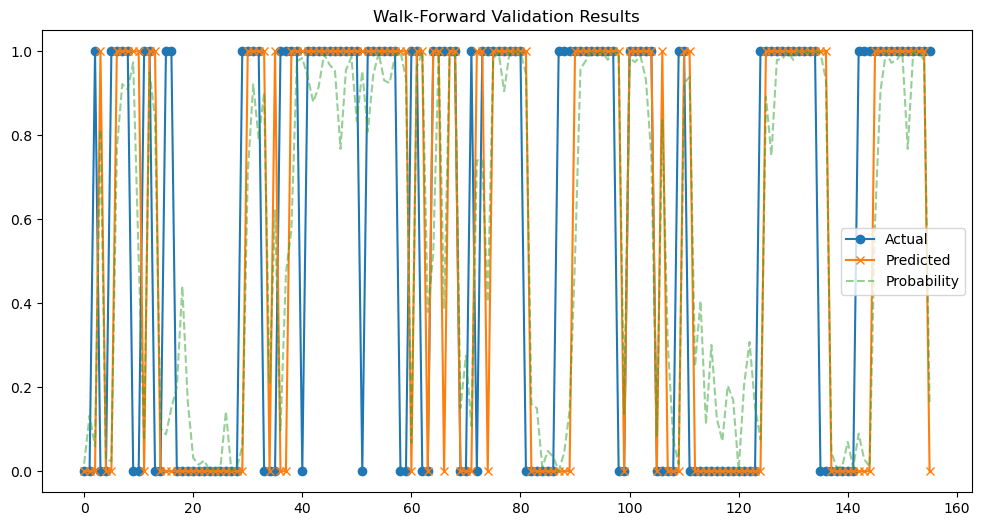

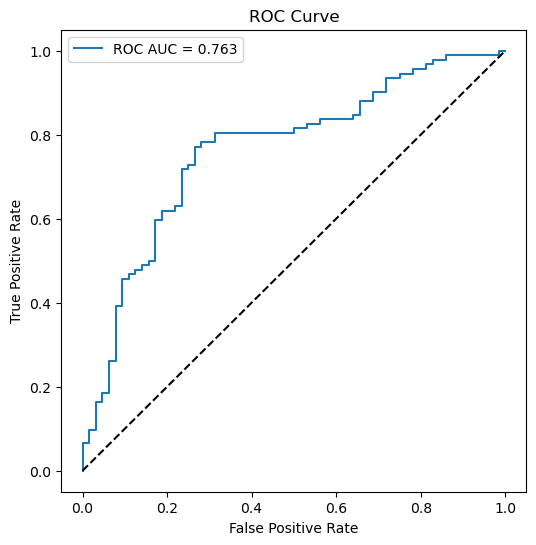

In [21]:
def main():
    # Prepare data
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()

    # Handle inf/NaN (XGBoost handles NaNs natively, but we cap inf)
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

    print("=== PHASE 1: INITIAL HYPERPARAMETER TUNING ===")
    # You may want to tune only on pre-test data:
    X_train_full = X[:-FINAL_TEST_POINTS]
    y_train_full = y[:-FINAL_TEST_POINTS]

    best_params = tune_hyperparameters(X_train_full, y_train_full)

    print("\n=== PHASE 2: ADAPTIVE ROLLING WALK-FORWARD ===")
    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(
        X, y,
        n_test=FINAL_TEST_POINTS,
        base_params=best_params,
        retune_every=52,      # yearly retuning
        lookback=360          # 5-year rolling window
    )

    print("\n=== ADAPTIVE PARAMS RESULTS ===")
    plot_wfv_results(actuals_adapt, preds_adapt, probs_adapt)

    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "adaptive": (actuals_adapt, preds_adapt, probs_adapt),
    }


if __name__ == "__main__":
    results_xgb = main()



In [22]:
#results = main()

actuals_adapt = results_xgb["adaptive"][0]
preds_adapt   = results_xgb["adaptive"][1]
probs_adapt   = results_xgb["adaptive"][2]


df_probs = pd.DataFrame({
    "Date": data.index[-len(probs_adapt):],
    "actual": actuals_adapt,
    "prediction": preds_adapt,
    "probability": probs_adapt
}).set_index("Date")


In [23]:
df_probs.to_csv('momentum_value_probs.csv',index=True)


In [24]:
print(df_probs)

            actual  prediction  probability
Date                                       
2022-04-11       0           0     0.017982
2022-04-18       0           0     0.132428
2022-04-25       1           0     0.059310
2022-05-02       0           1     0.813404
2022-05-09       0           0     0.028936
...            ...         ...          ...
2025-03-03       1           1     0.767418
2025-03-10       1           1     0.998898
2025-03-17       1           1     0.998712
2025-03-24       1           1     0.978379
2025-03-31       1           0     0.160600

[156 rows x 3 columns]



=== XGBoost SHAP Global Importance ===
GlobalBondVol6                          0.406295
mom1m_momentum_vs_value                 0.391900
corr_momentum_value_12                  0.380611
SA_RB_Curvature                         0.365765
zrel_value_vs_quality_12                0.351931
EURUSDV6M.Curncy_QS                     0.347460
volratio_momentum_value_12              0.315738
mom1m_momentum_vs_quality               0.314158
US_RB_Curvature                         0.312494
relvol_momentum_vs_value_12             0.311322
MXWD.Index.PE.Ratio_QS                  0.304846
GLD_RollKurt                            0.297632
JALSH_Fundamental_PC1                   0.287893
TOP40.Index.Price.to.Ebitda_Diff        0.283487
TOP40.Index.Price.to.Book.Ratio_Diff    0.283092
GlobalPropertyVol12                     0.272639
SA_NB_Slope                             0.266640
GLD_RollSD                              0.262501
relvol_momentum_vs_quality_12           0.248692
GenComIndexPC1_QS            

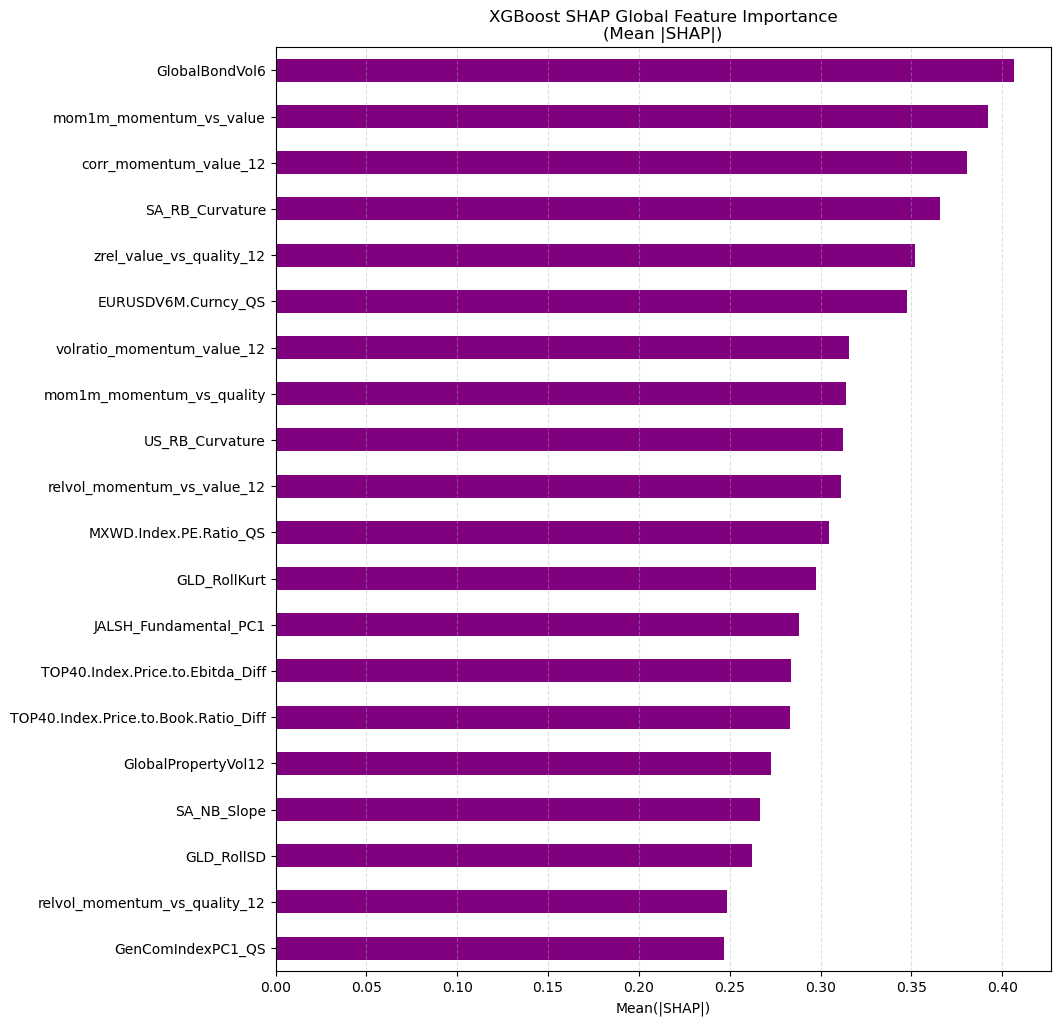

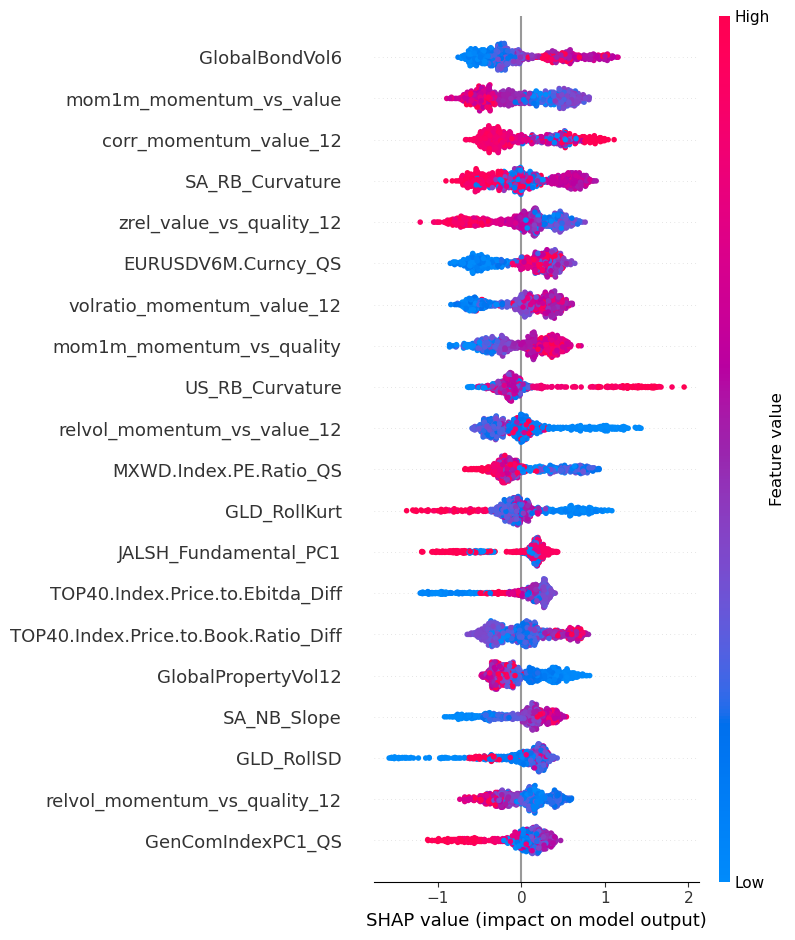

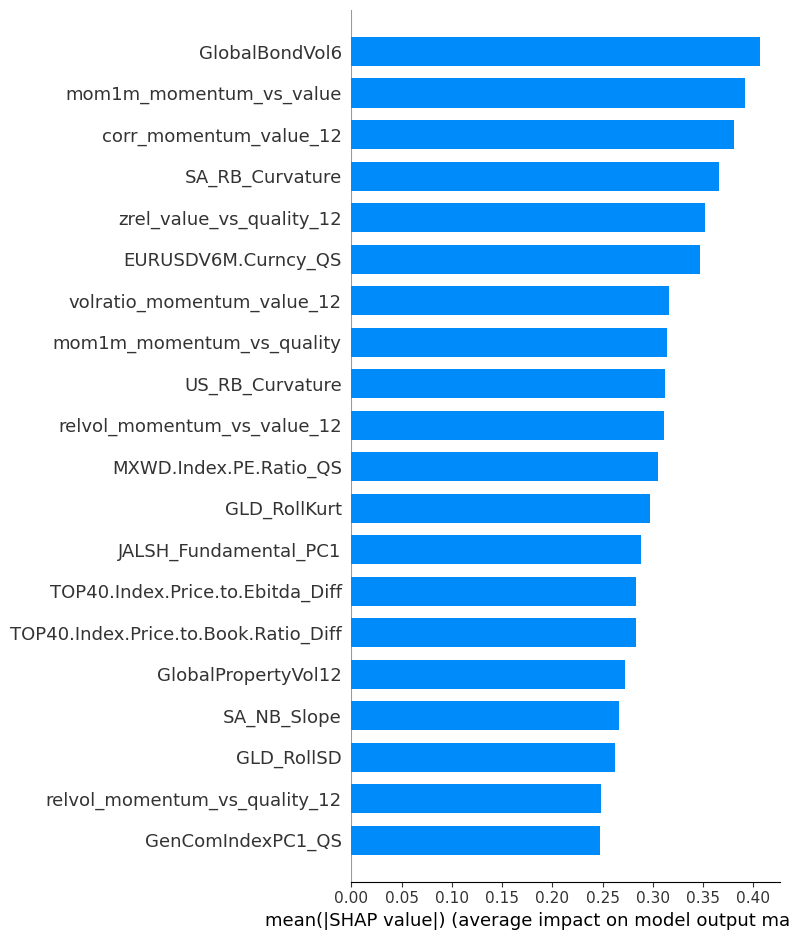

In [ ]:
# ============================================
# XGBoost SHAP FEATURE IMPORTANCE (TREE SHAP)
# ============================================

import shap

# Data prep
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
feature_names = results_xgb["feature_names"]
X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

train_end = len(X) - FINAL_TEST_POINTS
X_train_final = X[:train_end]
y_train_final = y[:train_end]

# Final model
best_params = results_xgb["best_params"]

final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    #n_estimators=500,
   # use_label_encoder=False,
    **best_params
)
final_model.fit(X_train_final, y_train_final)

# SHAP Values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_final)

# Global importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print("\n=== XGBoost SHAP Global Importance ===")
print(shap_importance.head(20))

# Plot bar chart
plt.figure(figsize=(10, 12))
shap_importance.head(20).plot(kind='barh', color='purple')
plt.title("XGBoost SHAP Global Feature Importance\n(Mean |SHAP|)")
plt.xlabel("Mean(|SHAP|)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

# Summary plots
shap.summary_plot(shap_values, X_train_final, feature_names=feature_names, plot_type="dot")
shap.summary_plot(shap_values, X_train_final, feature_names=feature_names, plot_type="bar")


In [26]:
shap = shap_importance.head(20)
shap.to_csv('global_shap_importance.csv')